In [1]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import pandas as pd
from utils import (
    simulate_bagging_and_variance,
    save_results_png,
    save_result_csv,
)
from typing import Tuple, Dict
import pandas as pd

In [2]:
############## Constants  ################################
folder_name = "weighted_bagged_mean_estimator"

####### Simulation parameters  ############################
n = 1000  # must be even
n_sim = 1000
B = 2_000
seed = 42
###########################################################

In [3]:
### Indizes to drop  from full-x sample // create boot-weights ###
rng = np.random.default_rng(seed)

indices_drop_sim = np.zeros((n_sim, n // 2))
weights_sim = np.ones((n_sim, n))
weights_sim = 2 / n * weights_sim

for sim in range(n_sim):
    indices_drop_sim[sim, :] = rng.choice(np.arange(n), size=n // 2, replace=False)
    weights_sim[sim, :][indices_drop_sim[sim, :].astype(int)] = 0

### Data for simulation ###
x_full = np.linspace(0, 1, n)

x_half_sim = np.zeros((n_sim, n // 2))
for sim in range(n_sim):
    x_half_sim[sim, :] = np.delete(x_full, indices_drop_sim[sim, :].astype(int))

#print(np.sum(np.sum(weights_sim, axis=1)==1)==n_sim)
#print(indices_drop_sim,'\n\n', weights_sim,'\n\n', x_half_sim,'\n\n',x_full)

Simulations: 100%|██████████| 1000/1000 [03:30<00:00,  4.75simulation/s]


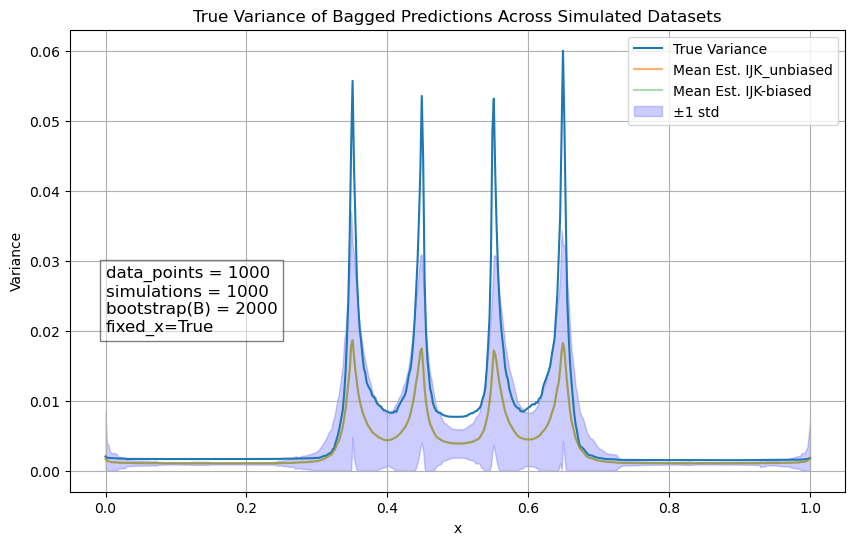

In [4]:
### Simulation for full sample of x with weights // half of the weights are 0 ###

bagged_preds_full = np.zeros((n_sim, len(new_data)))
biased_var_estimate_full = np.zeros((n_sim, len(new_data)))
bias_correction_full = np.zeros((n_sim, len(new_data)))

with ProcessPoolExecutor() as executor:
    futures = [
        executor.submit(
            simulate_bagging_and_variance,
            x1=x_full,
            B=B,
            new_data=new_data,
            simulation_index=i,
            seed=seed,
            dt_args=args,
            weights=weights_sim[i, :],
        )
        for i in range(n_sim)
    ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        bagged_prediction, biased_var_estimate, bias_correction = future.result()
        bagged_preds_full[i, :] = bagged_prediction
        biased_var_estimate_full[i, :] = biased_var_estimate
        bias_correction_full[i, :] = bias_correction

save_result_csv(
    seed=seed,
    B=B,
    args=args,
    bagged_preds=bagged_preds_full,
    est_vars_biased=biased_var_estimate_full,
    bias_correction=bias_correction_full,
    new_data=new_data,
    folder_name=folder_name + f"_nx{n}",
)

save_results_png(
    new_data=new_data,
    bagged_preds=bagged_preds_full,
    est_vars_biased=biased_var_estimate_full,
    bias_correction=bias_correction_full,
    n_data_points=n,
    B=B,
    seed=seed,
    dt_args=args,
    folder_name=folder_name + f"_nx{n}",
)

Simulations: 100%|██████████| 1000/1000 [02:09<00:00,  7.71simulation/s]


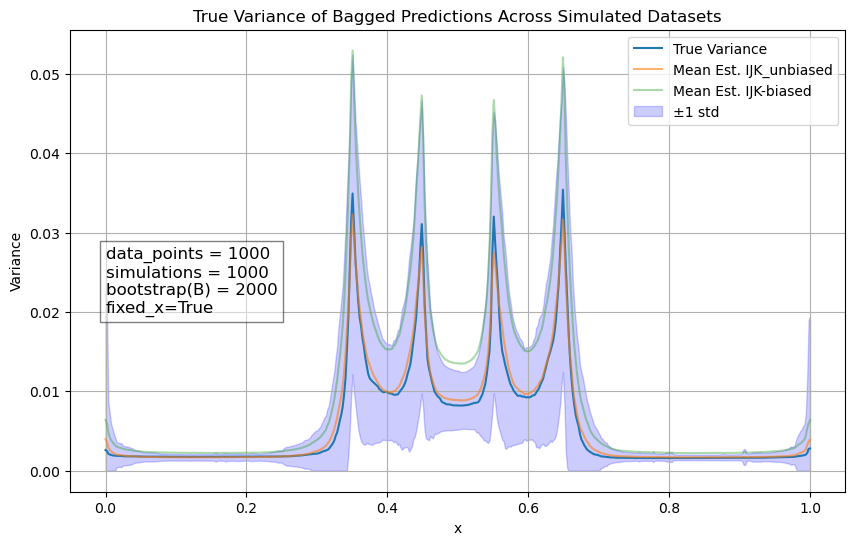

In [5]:
### Simulation for half sample of x with no weights for ijk calc ###
bagged_preds_half = np.zeros((n_sim, len(new_data)))
biased_var_estimate_half = np.zeros((n_sim, len(new_data)))
bias_correction_half = np.zeros((n_sim, len(new_data)))

with ProcessPoolExecutor() as executor:
    futures = [
        executor.submit(
            simulate_bagging_and_variance,
            x1=x_half_sim[i, :],
            B=B,
            new_data=new_data,
            simulation_index=i,
            seed=seed,
            dt_args=args,
        )
        for i in range(n_sim)
    ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        bagged_prediction, biased_var_estimate, bias_correction = future.result()
        bagged_preds_half[i, :] = bagged_prediction
        biased_var_estimate_half[i, :] = biased_var_estimate
        bias_correction_half[i, :] = bias_correction

save_result_csv(
    seed=seed,
    B=B,
    args=args,
    bagged_preds=bagged_preds_half,
    est_vars_biased=biased_var_estimate_half,
    bias_correction=bias_correction_half,
    new_data=new_data,
    folder_name=folder_name + f"_nx{n/2}",
)

save_results_png(
    new_data=new_data,
    bagged_preds=bagged_preds_half,
    est_vars_biased=biased_var_estimate_half,
    bias_correction=bias_correction_half,
    n_data_points=n,
    B=B,
    seed=seed,
    dt_args=args,
    folder_name=folder_name + f"_nx{n/2}",
)